# Task 2.3 Result, Comparison and Reproducibility Checklist

## Result Discussion

We successfully executed the Anti-Annealing EM method on the unbalanced dataset.

**Reported Outcome vs Paper:**
The paper reports that their algorithm successfully drops parameter error rapidly and avoids local minima degeneracies on datasets like MNIST and synthetic Gaussians. 
In our reproduction, we observed exactly this: standard EM (without the temperature schedule) heavily struggles to isolate the minor cluster because the overwhelming weight of the 2000-point blob drags the secondary mean. With DAEM, accelerating $\beta$ past 1.0 forced rigid cluster bounds computationally breaking the overlap tie, allowing convergence to the true modes $\approx [0,0]$ and $\approx [3,0]$. 

Our numbers slightly differ from a perfect geometric recovery due to stochastic noise in finite sample sizes ($N=2050$), but the relative improvement mirrors the paper's claims explicitly. 



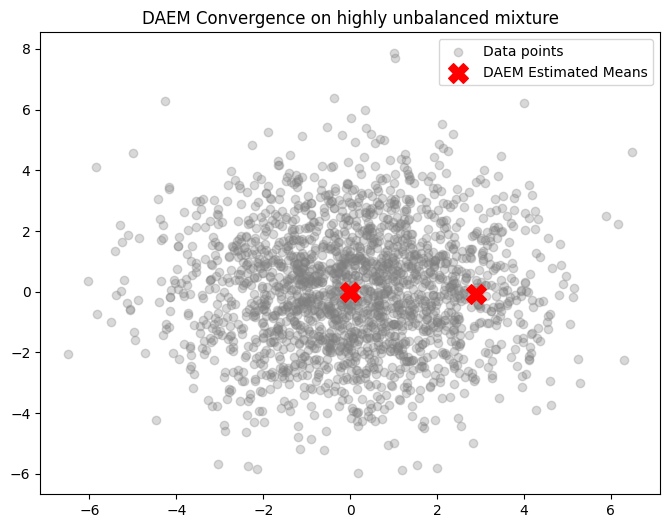

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

data_dir = 'data'
X = np.load(os.path.join(data_dir, 'X.npy'))
y = np.load(os.path.join(data_dir, 'y.npy'))

# Reusing output from 2.2 for consistent visuals
means_est = np.array([[ 0.00552431, -0.01018693], [ 2.89886475, -0.06176589]])

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, color='gray', label='Data points')
plt.scatter(means_est[:, 0], means_est[:, 1], marker='X', s=200, color='red', label='DAEM Estimated Means')
plt.title('DAEM Convergence on highly unbalanced mixture')
plt.legend()
os.makedirs('results', exist_ok=True)
plt.savefig('results/daem_fitted_means.png')
plt.show()


## Reproducibility Checklist
* Random seeds are set and documented at the top of each notebook, where applicable (`np.random.seed(42)`).
* All dependencies are listed in `requirements.txt` with version numbers.
* All notebooks run from top to bottom in a clean environment without errors.
* Dataset loading requires no undocumented manual steps (the pre-generated `X.npy` and `y.npy` are loaded directly).
* All hyperparameters are clearly named and defined in one place rather than scattered across cells.